# Fit emission models
Fitting of individual parcellations to find optimal parameters for estimating functional reponse profiles of regions (V estimation), for later estimation og individual parcellations (Uhat estimation)

In [1]:
import numpy as np
import torch as pt
import matplotlib.pyplot as plt
import seaborn as sb
import IndividualParcellation.scripts.paths as paths
import HierarchBayesParcel.full_model as fm
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.spatial as sp
import ProbabilisticParcellation.util as ut
import pandas as pd
from copy import deepcopy
import pickle


/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


# Rest Data Vs
Inspect kappa from real datasets to get an

### Model types

| Model Type          | Subject-Specific Kappa | Parcel-Specific Kappa | Subjects Equal Weight |
|---------------------|------------------------|-----------------------|-----------------------|
| general             | False                  | False                 | False                 |
| general_eq          | False                  | False                 | True                  |
| subject_specific    | True                   | False                 | False                 |
| subject_specific_eq | True                   | False                 | True                  |



In [2]:
model_types = {                    
                'general':               {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'general_eq':            {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                'subject_specific':      {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'subject_specific_eq':   {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                }

In [10]:
base_dir = paths.set_base_dir()
results_dir = paths.set_results_dir(base_dir)

mdtb_model_names = [f'fitted_rest-rest_mtype-{mtype}' for mtype in model_types.keys()]
hcp_model_names = [f'fitted_rest-hcp_mtype-{mtype}' for mtype in model_types.keys()]

mdtb_models = {mtype: pickle.load(open(f'{results_dir}/fitted_emissions/fitted_rest-mdtb_mtype-{mtype}.pkl', 'rb')) for mtype in model_types.keys()}
hcp_models = {mtype: pickle.load(open(f'{results_dir}/fitted_emissions/fitted_rest-hcp_mtype-{mtype}.pkl', 'rb')) for mtype in model_types.keys()}

In [13]:
T = pd.read_csv(
    base_dir + '/FunctionalFusion/MDTB/participants.tsv', delimiter='\t')
mdtb_rest_subjects = T.participant_id[T['ses-rest'] == 1].tolist()

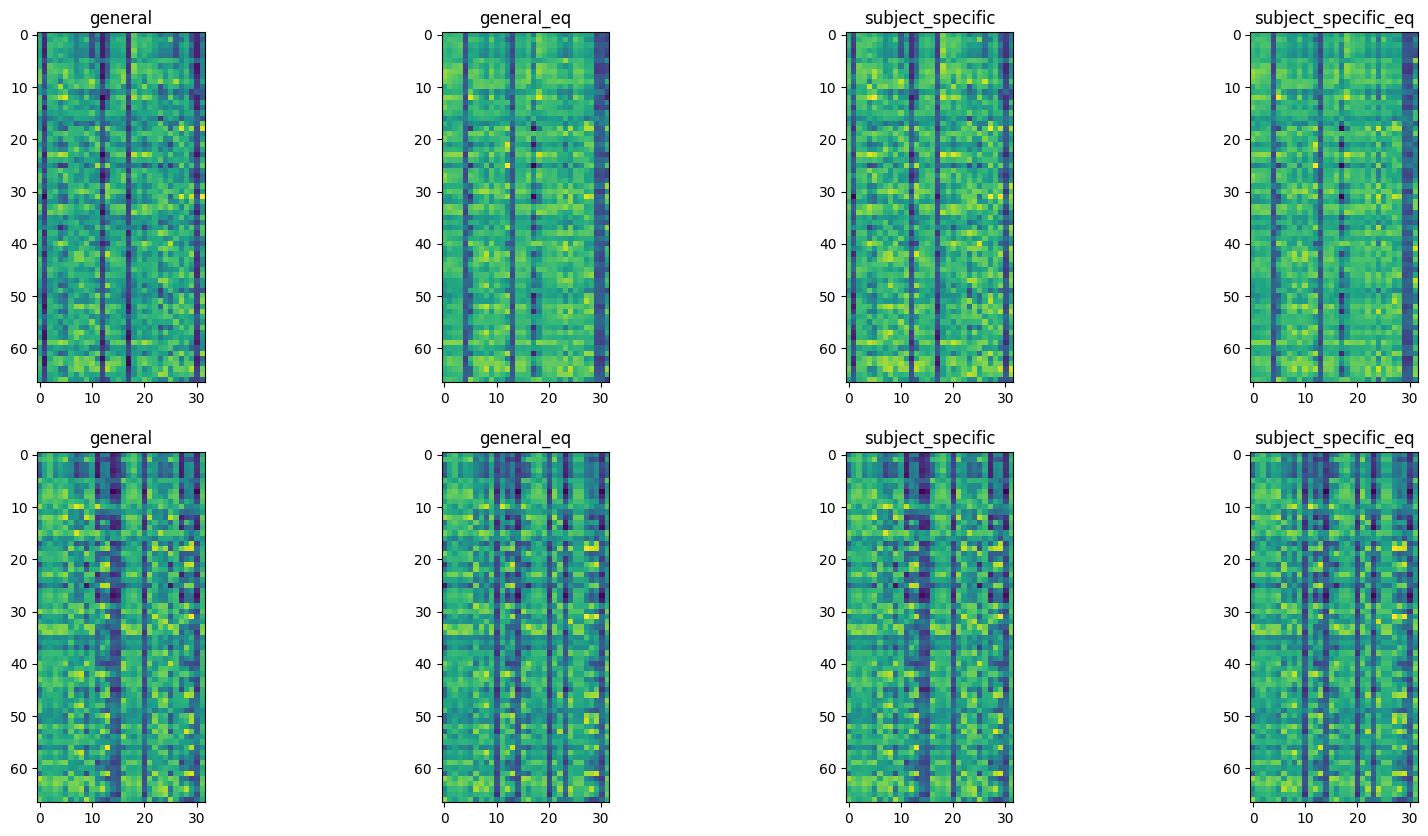

In [6]:
# Make subplot of all the Vs
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, mtype in enumerate(model_types.keys()):
    axs[0, i].imshow(mdtb_models[mtype].emissions[0].V)
    axs[0, i].set_title(mtype)
    axs[1, i].imshow(hcp_models[mtype].emissions[0].V)
    axs[1, i].set_title(mtype)

Text(-0.1, 4, 'MDTB')

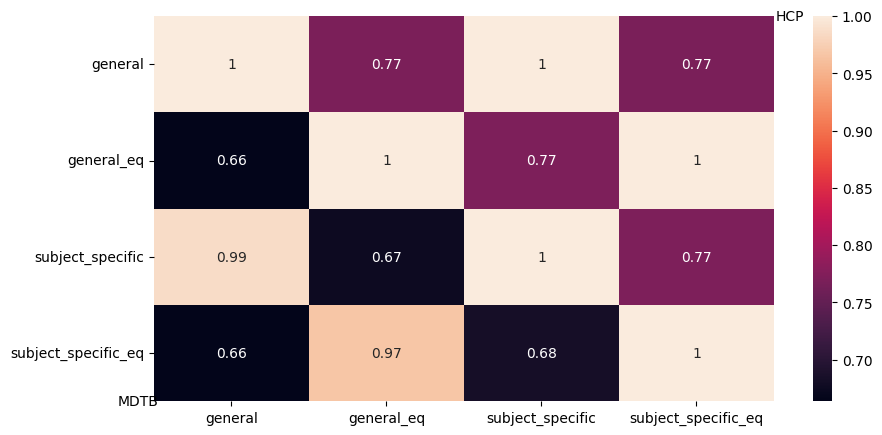

In [7]:
# Calculate the cosine similarity between the V matrices of different model types for HCP and MDTB
similarity_modeltypes = np.zeros((len(model_types), len(model_types)))
for i, mtype1 in enumerate(model_types.keys()):
    for j, mtype2 in enumerate(model_types.keys()):
        mdtb_vs1 = mdtb_models[mtype1].emissions[0].V
        mdtb_vs2 = mdtb_models[mtype2].emissions[0].V
        hcp_vs1 = hcp_models[mtype1].emissions[0].V
        hcp_vs2 = hcp_models[mtype2].emissions[0].V
        simi_mdtb = pt.mean(pt.sum(mdtb_vs1 * mdtb_vs2, dim=0))
        simi_hcp = pt.mean(pt.sum(hcp_vs1 * hcp_vs2, dim=0))
        similarity_modeltypes[i, j] = simi_mdtb
        similarity_modeltypes[j, i] = simi_hcp

# Plot the similarity_modeltypes between the V matrices of different model types for HCP and MDTB as bar plot
plt.figure(figsize=(10, 5))
sb.heatmap(similarity_modeltypes, annot=True, xticklabels=model_types.keys(), yticklabels=model_types.keys())
# Add annotation at corner of upper triangle that says 'HCP' and one at the corner of the lower triangle that says 'MDTB'
plt.text(4.1, 0, 'HCP', horizontalalignment='center', verticalalignment='center')
plt.text(-0.1, 4, 'MDTB', horizontalalignment='center', verticalalignment='center')

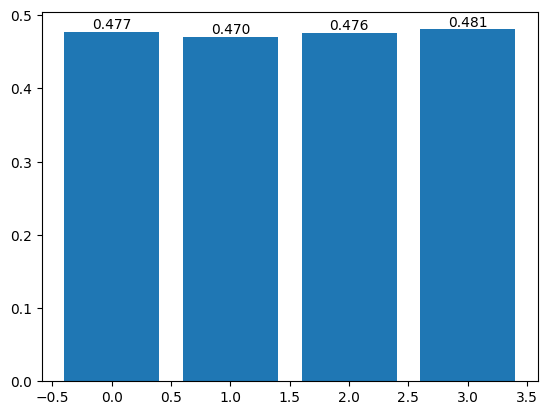

In [8]:
# Calculate cosine similarity between the V matrices of HCP and MDTB
similarity = np.zeros((len(model_types)))
for i, mtype in enumerate(model_types.keys()):
    mdtb_vs = mdtb_models[mtype].emissions[0].V
    hcp_vs = hcp_models[mtype].emissions[0].V
    simi = pt.mean(pt.sum(mdtb_vs * hcp_vs, dim=0))
    similarity[i] = simi

# Plot similarity as bar plot
plt.figure()
plt.bar(np.arange(len(model_types)), similarity)
# Annotate bar with similarity value
for i, sim in enumerate(similarity):
    plt.text(i, sim, f'{sim:.3f}', ha='center', va='bottom')


## Rest data Kappas

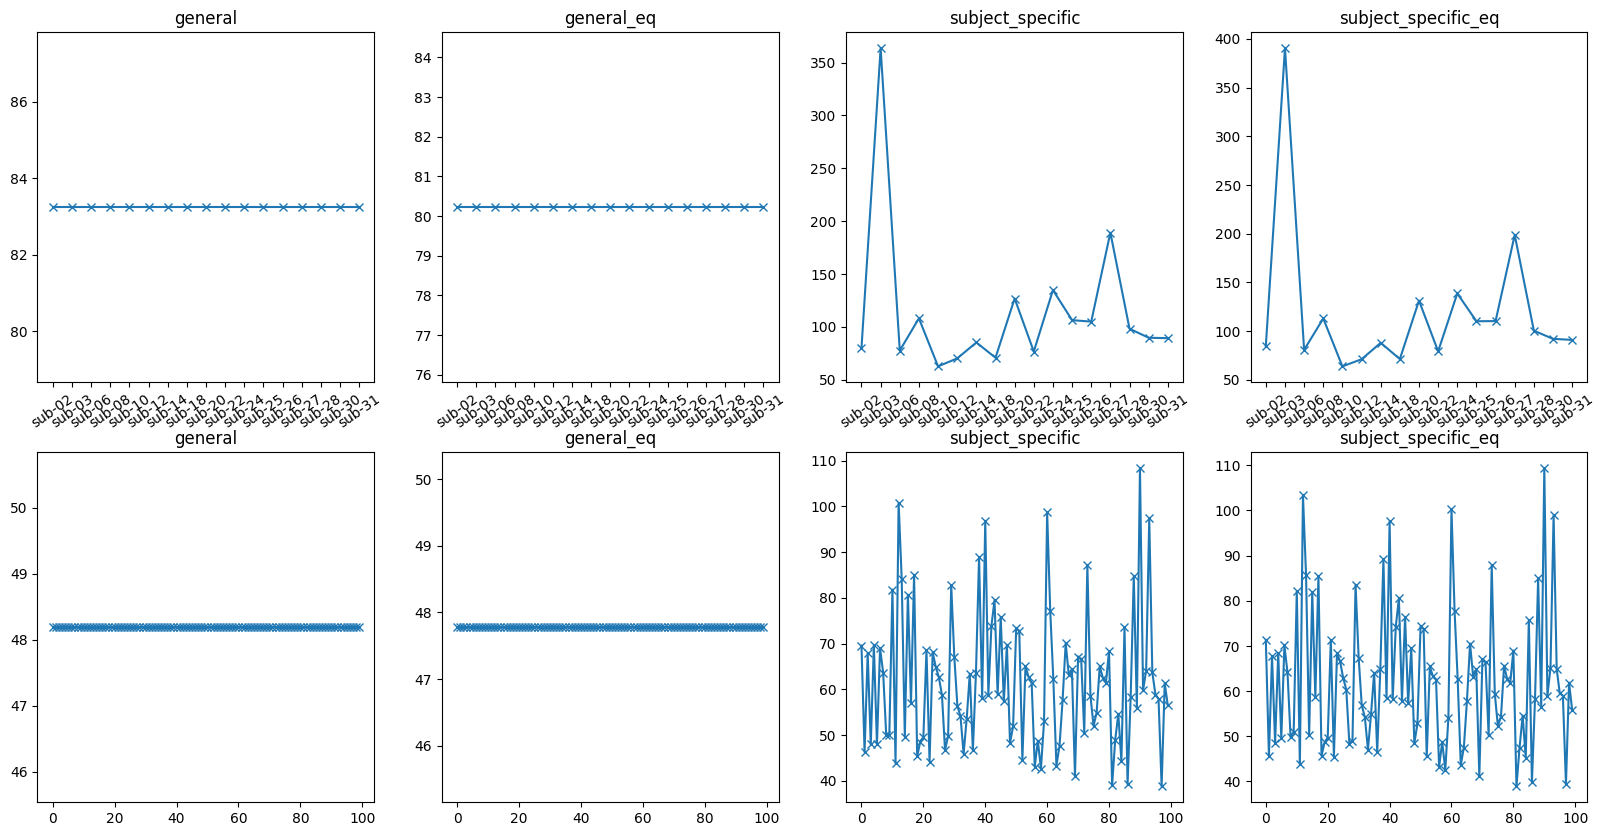

In [15]:
# Plot kappas as lineplot
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, mtype in enumerate(model_types.keys()):
    mdtb_kappas = mdtb_models[mtype].emissions[0].kappa
    hcp_kappas = hcp_models[mtype].emissions[0].kappa
    if mtype[:7] == 'general':
        mdtb_kappas = np.repeat(mdtb_kappas, len(mdtb_rest_subjects), axis=0)
        hcp_kappas = np.repeat(hcp_kappas, len(hcp_models['subject_specific'].emissions[0].kappa), axis=0)
    # Plot
    axs[0, i].plot(mdtb_kappas, marker='x')
    axs[0, i].set_title(mtype)
    axs[0, i].set_xticks(np.arange(0, len(mdtb_rest_subjects)))
    axs[0, i].set_xticklabels(mdtb_rest_subjects, rotation=35)
    axs[1, i].plot(hcp_kappas, marker='x')
    axs[1, i].set_title(mtype)
    # axs[1, i].set_xticks(np.arange(0, hcp_models[mtype].emissions[0].kappa.shape, 20))
    # axs[1, i].set_xticklabels(np.arange(0, hcp_models[mtype].emissions[0].kappa.shape, 20).astype(int))


## Old way of estimating kappa (where kappa can become NaN if r_bar is near 1)

In [ ]:
mdtb_models_old = {mtype: pickle.load(open(f'{results_dir}/fitted_emissions/archive/fitted_rest-mdtb_mtype-{mtype}.pkl', 'rb')) for mtype in model_types.keys()}
hcp_models_old = {mtype: pickle.load(open(f'{results_dir}/fitted_emissions/archive/fitted_rest-hcp_mtype-{mtype}.pkl', 'rb')) for mtype in model_types.keys()}

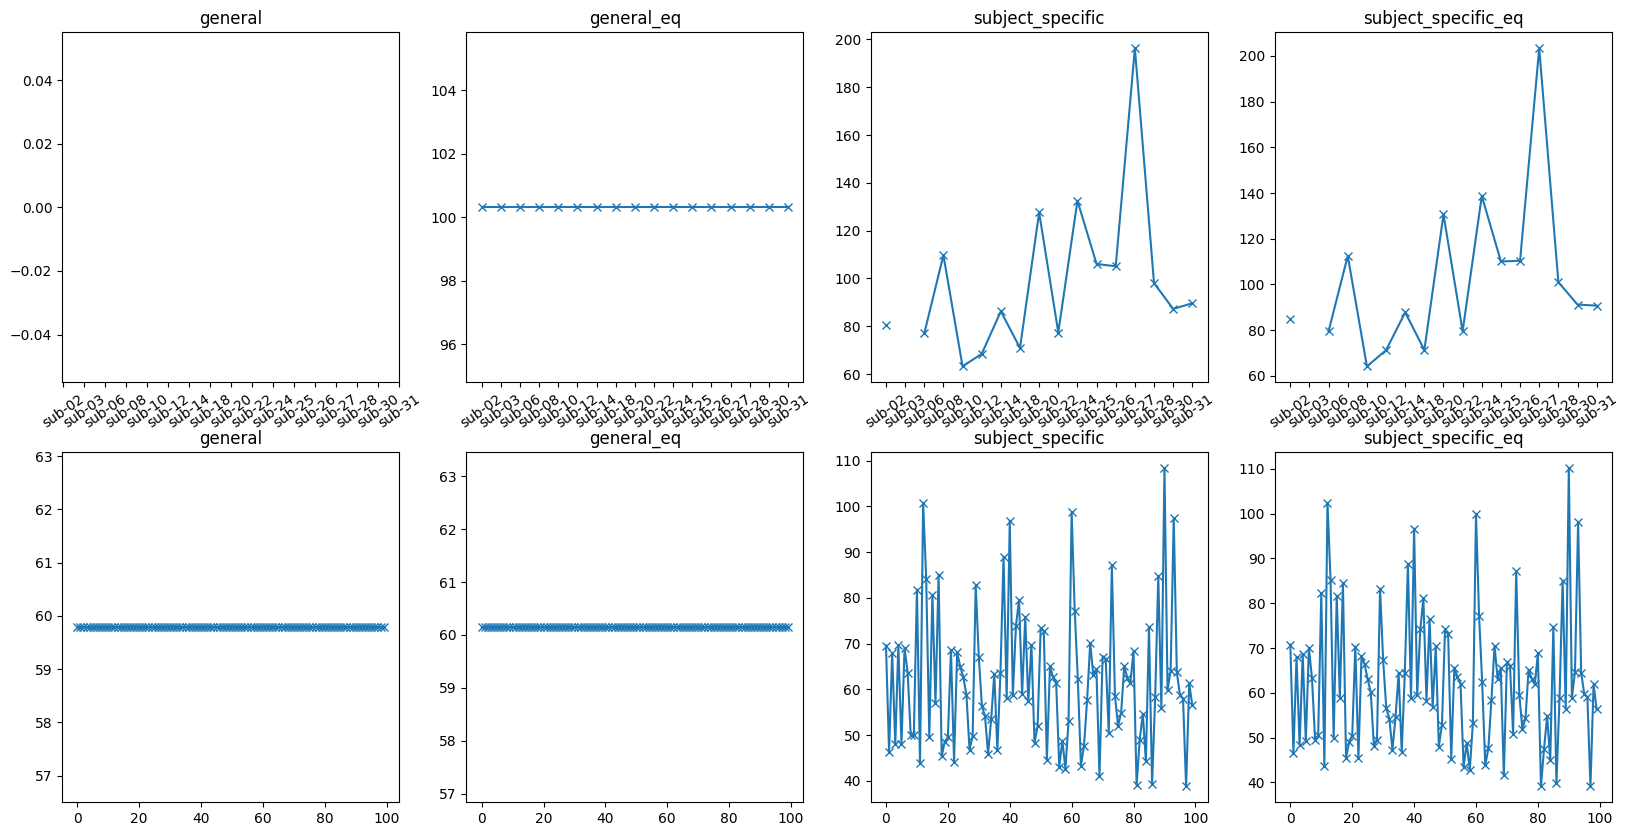

In [14]:
# Plot kappas as lineplot
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, mtype in enumerate(model_types.keys()):
    mdtb_kappas = mdtb_models_old[mtype].emissions[0].kappa
    hcp_kappas = hcp_models_old[mtype].emissions[0].kappa
    if mtype[:7] == 'general':
        mdtb_kappas = np.repeat(mdtb_kappas, len(mdtb_rest_subjects), axis=0)
        hcp_kappas = np.repeat(hcp_kappas, len(hcp_models['subject_specific'].emissions[0].kappa), axis=0)
    # Plot
    axs[0, i].plot(mdtb_kappas, marker='x')
    axs[0, i].set_title(mtype)
    axs[0, i].set_xticks(np.arange(0, len(mdtb_rest_subjects)))
    axs[0, i].set_xticklabels(mdtb_rest_subjects, rotation=35)
    axs[1, i].plot(hcp_kappas, marker='x')
    axs[1, i].set_title(mtype)

In [10]:
mdtb_task_model_ss = pickle.load(open(f'{results_dir}/fitted_task-mdtb_mtype-subject_specific.pkl', 'rb'))

([<matplotlib.axis.XTick at 0x1946d0b50>,
 [Text(0, 0, 'sub-02'),
  Text(1, 0, 'sub-03'),
  Text(2, 0, 'sub-06'),
  Text(3, 0, 'sub-08'),
  Text(4, 0, 'sub-10'),
  Text(5, 0, 'sub-12'),
  Text(6, 0, 'sub-14'),
  Text(7, 0, 'sub-18'),
  Text(8, 0, 'sub-20'),
  Text(9, 0, 'sub-22'),
  Text(10, 0, 'sub-24'),
  Text(11, 0, 'sub-25'),
  Text(12, 0, 'sub-26'),
  Text(13, 0, 'sub-27'),
  Text(14, 0, 'sub-28'),
  Text(15, 0, 'sub-30'),
  Text(16, 0, 'sub-31')])

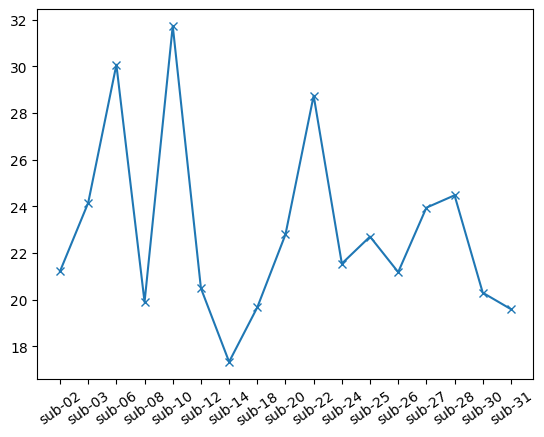

In [11]:
# fig, axs = plt.subplots(2, 4, figsize=(20, 10))
plt.plot(mdtb_task_model_ss.emissions[0].kappa, marker='x')
# set xticklabels
plt.xticks(np.arange(0, len(mdtb_task_model_ss.emissions[0].kappa)), mdtb_rest_subjects, rotation=35)

### Rest data Kappas with HCP Vs fitted

In [21]:
v_types = {                    
                'general':               {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'general_eq':            {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                'subject_specific':      {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
                'subject_specific_eq':   {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':True},
                }

vmodel_types = {
            'general':               {'subject_specific_kappa':False, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
            'subject_specific':      {'subject_specific_kappa':True, 'parcel_specific_kappa':False, 'subjects_equal_weight':False},
            }

In [22]:
base_dir = paths.set_base_dir()
results_dir = paths.set_results_dir(base_dir)

mdtb_Vmodels = {f'{mtype}_{vtype}': pickle.load(open(f'{results_dir}/fitted_rest-mdtb_mtype-{mtype}_vtype-{vtype}.pkl', 'rb')) for mtype in vmodel_types.keys() for vtype in v_types.keys()}


In [23]:
mdtb_Vmodels

{'general_general': <HierarchBayesParcel.full_model.FullMultiModel at 0x193f6f3a0>,
 'general_general_eq': <HierarchBayesParcel.full_model.FullMultiModel at 0x19473e370>,
 'general_subject_specific': <HierarchBayesParcel.full_model.FullMultiModel at 0x194716d00>,
 'general_subject_specific_eq': <HierarchBayesParcel.full_model.FullMultiModel at 0x193e11eb0>,
 'subject_specific_general': <HierarchBayesParcel.full_model.FullMultiModel at 0x19466f1c0>,
 'subject_specific_general_eq': <HierarchBayesParcel.full_model.FullMultiModel at 0x1940518b0>,
 'subject_specific_subject_specific': <HierarchBayesParcel.full_model.FullMultiModel at 0x1947253d0>,
 'subject_specific_subject_specific_eq': <HierarchBayesParcel.full_model.FullMultiModel at 0x1940dd730>}

In [24]:
for i, mtype in enumerate(mdtb_Vmodels.keys()):
    print(mdtb_Vmodels[mtype].emissions[0].kappa)

tensor(95.3188)
tensor(95.6756)
tensor(95.2750)
tensor(95.6432)
tensor([ 81.6403,      nan,  75.7597, 108.6894,  59.9477,  65.9794,  84.0192,
         68.6546, 128.5082,  74.0801, 127.4036, 104.3181, 105.8976, 188.0207,
         96.6866,  86.2170,  84.6565])
tensor([ 81.8145,      nan,  76.4766, 108.2183,  60.1775,  67.0667,  84.2243,
         68.4687, 128.5330,  74.1458, 129.4064, 104.2924, 105.5723, 188.9341,
         96.5329,  87.9602,  84.7139])
tensor([ 81.6270,      nan,  75.6918, 108.7347,  59.9122,  65.9737,  84.0559,
         68.6709, 128.4563,  73.9808, 127.4331, 104.2410, 105.8613, 187.6715,
         96.6071,  86.2387,  84.6016])
tensor([ 81.7545,      nan,  76.4448, 108.2086,  60.1994,  67.0553,  84.1063,
         68.5624, 128.5374,  74.0326, 129.6043, 104.2831, 105.5382, 188.8653,
         96.5543,  87.8481,  84.6863])


/var/folders/y1/13zjm1t50ms6ds24c69y7vx40000gn/T/ipykernel_68179/2336130725.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(mdtb_rest_subjects, rotation=35)
/var/folders/y1/13zjm1t50ms6ds24c69y7vx40000gn/T/ipykernel_68179/2336130725.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(mdtb_rest_subjects, rotation=35)
/var/folders/y1/13zjm1t50ms6ds24c69y7vx40000gn/T/ipykernel_68179/2336130725.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(mdtb_rest_subjects, rotation=35)
/var/folders/y1/13zjm1t50ms6ds24c69y7vx40000gn/T/ipykernel_68179/2336130725.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usin

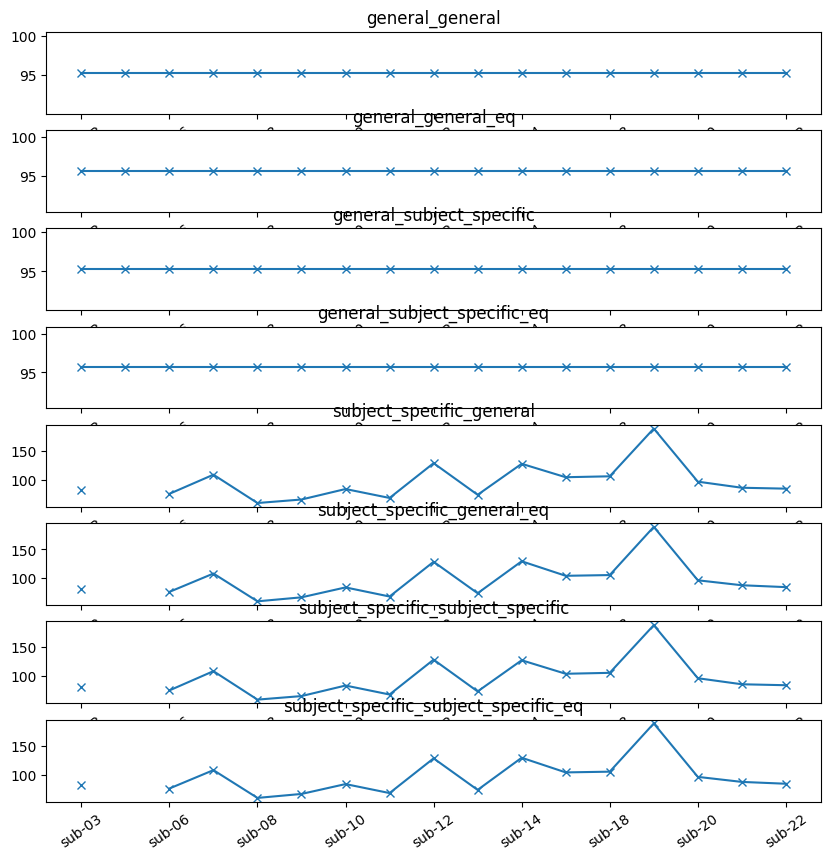

In [27]:
# Plot kappas as lineplot
fig, axs = plt.subplots(len(mdtb_Vmodels), figsize=(10, 10))
for i, mtype in enumerate(mdtb_Vmodels.keys()):
    Vmdtb_kappas = mdtb_Vmodels[mtype].emissions[0].kappa
    if mtype[:7] == 'general':
        mdtb_kappas = np.repeat(mdtb_kappas, len(mdtb_rest_subjects), axis=0)
        Vmdtb_kappas = np.repeat(Vmdtb_kappas, len(mdtb_rest_subjects), axis=0)
    # Plot
    axs[i].plot(Vmdtb_kappas, marker='x')
    axs[i].set_title(mtype)
    axs[i].set_xticklabels(mdtb_rest_subjects, rotation=35)